In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from brian2 import *
import functions as fc
import numpy as np

In [3]:
from matplotlib.gridspec import GridSpec
import plot_config

In [4]:
simtime3 = 300*10**3 * ms + 50*10**3 * ms
p_rcs = [0.1, 0.15, 0.25]

In [5]:
spikemons_t = []
spikemons_i = []
ratemons_t = []
ratemons_rate = []
currents_t = []
currents_I = []
currents_E = []
synmons_t = []
synmons_w = []
current_ass_E = []
current_ass_I = []
current_ass_t = []

for i, p_rc in enumerate(p_rcs):
    data = np.load(f'analysis_c_new_{i}.npz', allow_pickle=True)

    SpikeMon_t = data['SpikeMon_t'] 
    SpikeMon_i = data['SpikeMon_i'] 
    RateMonE_t = data['RateMonE_t'] 
    RateMonE_rate = data['RateMonE_rate'] 
    Current_t = data['Current_t'] 
    Current_inh = data['Current_inh']
    Current_exc = data['Current_exc']
    SynMon_t = data['SynMon_t']
    SynMon_w = data['SynMon_w']  

    ratemons_rate.append(RateMonE_rate)
    ratemons_t.append(RateMonE_t)
    spikemons_t.append(SpikeMon_t)
    spikemons_i.append(SpikeMon_i)

    currents_t.append(Current_t)
    currents_I.append(Current_inh)
    currents_E.append(Current_exc)

    synmons_t.append(SynMon_t)
    synmons_w.append(SynMon_w)

    current_ass_E.append(data['assembly_exc'])
    current_ass_I.append(data['assembly_inh'])
    current_ass_t.append(data['assembly_t'])

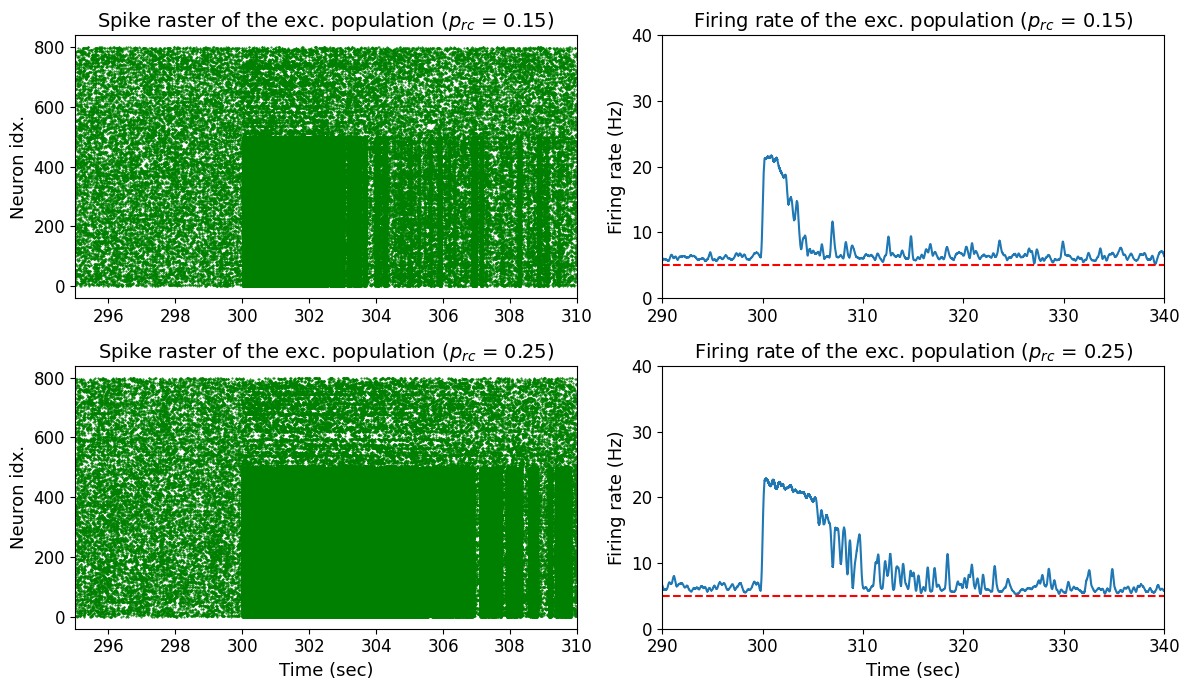

In [6]:
fig = plt.figure(figsize=(12, 7))
gs = GridSpec(2, 2, figure=fig, width_ratios=[1, 1])  

for i, j in enumerate(np.arange(1, len(p_rcs), 1)):
    ax1 = fig.add_subplot(gs[i, 0])
    ax1.plot(spikemons_t[j], spikemons_i[j], '.g', ms=1)
    ax1.set_xlim([295, 310])
    ax1.set_ylabel('Neuron idx.')
    ax1.set_title(f'Spike raster of the exc. population ($p_{{rc}}$ = {p_rcs[j]})')

    ax2 = fig.add_subplot(gs[i, 1])
    ax2.plot(ratemons_t[j], ratemons_rate[j], '', ms=1)
    ax2.set_xlim([0, simtime3/second])
    ax2.axhline(5, linestyle='--', color='red')
    ax2.set_ylim([0, 40])
    ax2.set_xlim([290, 340])
    ax2.set_ylabel('Firing rate (Hz)')
    ax2.set_title(f'Firing rate of the exc. population ($p_{{rc}}$ = {p_rcs[j]})')
    
    if i == 1:
        ax2.set_xlabel('Time (sec)')
        ax1.set_xlabel('Time (sec)')

plt.tight_layout()
plt.savefig('./Plots/fig_4.png', format='png', dpi=300, bbox_inches="tight")
plt.savefig('./Plots/fig_4.pdf', format='pdf', dpi=300, bbox_inches="tight")
plt.show()  

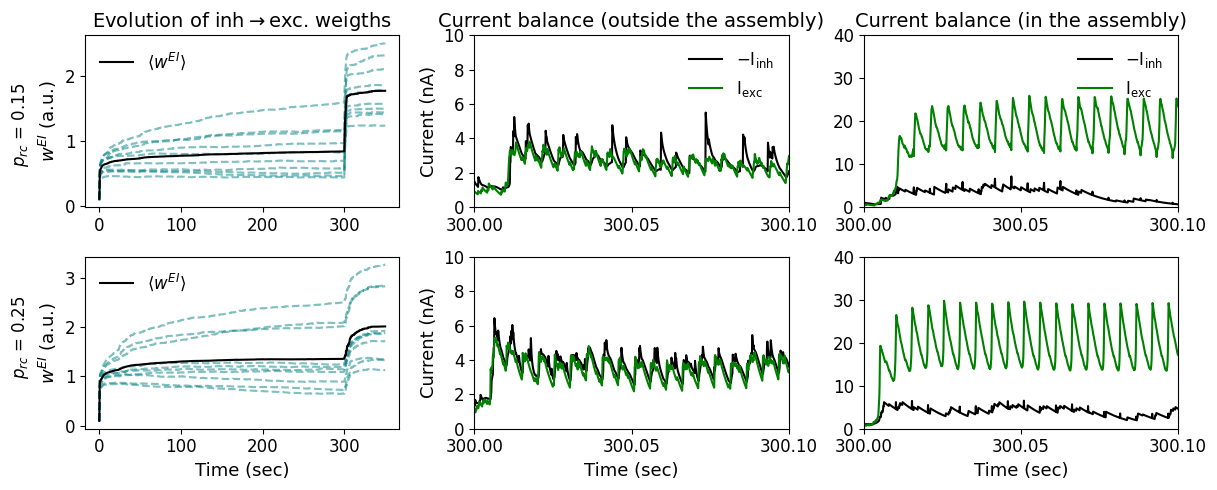

In [11]:
fig = plt.figure(figsize=(12, 5))
gs = GridSpec(2, 3, figure=fig, width_ratios=[1, 1, 1])  

for i, j in enumerate(np.arange(1, len(p_rcs), 1)):
    
    fig.text(-0.01, 0.74 - i*0.425, f'$p_{{rc}}$ = {p_rcs[j]}', fontsize=12, va='center', ha='left', rotation=90)

    ax1 = fig.add_subplot(gs[i, 0])
    ax1.plot(synmons_t[j], synmons_w[j], alpha=0.5, color='teal', ls='--')
    ax1.plot(synmons_t[j], np.mean(synmons_w[j], axis=1), label="$\\langle w^{EI} \\rangle$", color='black')
    ax1.legend(frameon=False, loc='upper left')
    ax1.set_ylabel('$w^{EI}$ (a.u.)')

    ax2 = fig.add_subplot(gs[i, 1])
    ax2.plot(currents_t[j], -currents_I[j][0], color='black', label="$-\\text{I}_{\\text{inh}}$")
    ax2.plot(currents_t[j], currents_E[j][0], color='green', label="$\\text{I}_{\\text{exc}}$")
    ax2.set_ylim([0, 10])
    ax2.set_xlim([300, 300.1])
    ax2.set_xticks([300, 300.05, 300.1])
    ax2.set_ylabel('Current (nA)')

    ax3 = fig.add_subplot(gs[i, 2])
    ax3.plot(current_ass_t[j], -current_ass_I[j][0], color='black', label="$-\\text{I}_{\\text{inh}}$")
    ax3.plot(current_ass_t[j], current_ass_E[j][0], color='green', label="$\\text{I}_{\\text{exc}}$")
    ax3.set_ylim([0, 40])
    ax3.set_xlim([300, 300.1])
    ax3.set_xticks([300, 300.05, 300.1])
    

    if i == 0:
        ax1.set_title('Evolution of inh$\\rightarrow$exc. weigths')
        ax2.set_title('Current balance (outside the assembly)')
        ax3.set_title('Current balance (in the assembly)')
        ax2.legend(frameon=False, loc='upper right')
        ax3.legend(frameon=False, loc='upper right')

    if i == 1:
        ax1.set_xlabel('Time (sec)')
        ax2.set_xlabel('Time (sec)')
        ax3.set_xlabel('Time (sec)')

plt.tight_layout()
plt.savefig('./Plots/fig_5.png', format='png', dpi=300, bbox_inches="tight")
plt.savefig('./Plots/fig_5.pdf', format='pdf', dpi=300, bbox_inches="tight")
plt.show()
